In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("liver_cirrhosis.csv")

In [ ]:
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,C,Placebo,18499,F,N,Y,N,N,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,C,Placebo,19724,M,Y,N,Y,N,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,C,Placebo,11839,F,N,N,N,N,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,D,Placebo,16467,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,D,Placebo,21699,F,N,Y,N,N,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


In [ ]:
df.shape

(25000, 19)

In [ ]:
df.isna().sum()

,0
N_Days,0
Status,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0
Bilirubin,0


In [ ]:
df.duplicated().sum()

np.int64(15361)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         25000 non-null  int64  
 1   Status         25000 non-null  object 
 2   Drug           25000 non-null  object 
 3   Age            25000 non-null  int64  
 4   Sex            25000 non-null  object 
 5   Ascites        25000 non-null  object 
 6   Hepatomegaly   25000 non-null  object 
 7   Spiders        25000 non-null  object 
 8   Edema          25000 non-null  object 
 9   Bilirubin      25000 non-null  float64
 10  Cholesterol    25000 non-null  float64
 11  Albumin        25000 non-null  float64
 12  Copper         25000 non-null  float64
 13  Alk_Phos       25000 non-null  float64
 14  SGOT           25000 non-null  float64
 15  Tryglicerides  25000 non-null  float64
 16  Platelets      25000 non-null  float64
 17  Prothrombin    25000 non-null  float64
 18  Stage 

## Dataset Column Insights

**General Observations:**
*   **Dataset Size**: The dataset contains 25000 entries and 19 columns.
*   **Missing Values**: Only the 'Stage' column has one missing value, which is a very small proportion of the total data and can be easily addressed.
*   **Duplicates**: There are 15361 duplicate rows, which is a significant number. These duplicates might represent repeated measurements, different records for the same patient, or data entry errors. It's crucial to understand their nature and decide whether to keep or remove them, as they could influence analysis and model training.
*   **Potential Target Variables**: 'Status' (C=censored/alive, D=dead) and 'Stage' (liver cirrhosis stage) are strong candidates for target variables, representing patient outcomes and disease severity, respectively.

**Column-wise Insights:**

1.  **N_Days**
    *   **Description**: This column represents the number of days since the patient's registration. It's a continuous numerical variable.
    *   **Data Type**: Integer (`int64`).
    *   **Observations**: Values are generally large integers (e.g., 2221, 1230, 4184), indicating duration. Higher values could imply longer follow-up or survival.
    *   **Effect on Target**: Likely a critical feature for survival analysis. Longer N_Days might correlate with a 'C' (censored/alive) status, indicating longer survival, or could represent the duration up to an event for 'D' (dead) status.

2.  **Status**
    *   **Description**: This is a categorical variable indicating the patient's outcome: 'C' for censored (meaning they were alive at the last follow-up or withdrawn) and 'D' for dead. This is highly likely to be a primary target variable for prediction models.
    *   **Data Type**: Object (string).
    *   **Observations**: Contains only 'C' and 'D' values.
    *   **Unique Counts**: 2 unique values.
    *   **Effect on Target**: This *is* a key outcome variable. All other features would be analyzed for their predictive power on this status.

3.  **Drug**
    *   **Description**: A categorical variable indicating the drug treatment received by the patient. Based on the sample, 'Placebo' is present.
    *   **Data Type**: Object (string).
    *   **Observations**: Contains 'Placebo' as seen in the head. There might be one or more active drug treatments as well.
    *   **Unique Counts**: At least 1 (Placebo), potentially more.
    *   **Effect on Target**: This is a crucial independent variable for evaluating treatment efficacy. Differences in 'Status' or 'Stage' among different drug groups would indicate treatment effects.

4.  **Age**
    *   **Description**: This column represents the patient's age. The values suggest it's likely measured in days, as they are large integers (e.g., 18499, 19724).
    *   **Data Type**: Integer (`int64`).
    *   **Observations**: Continuous numerical values. It would be beneficial to convert this to years for easier interpretation.
    *   **Unique Counts**: Many unique values, as expected for age.
    *   **Effect on Target**: Age is a significant prognostic factor for many diseases, including cirrhosis. Generally, older age might correlate with worse 'Status' (higher likelihood of 'D') and more advanced 'Stage').

5.  **Sex**
    *   **Description**: A categorical variable indicating the patient's biological sex.
    *   **Data Type**: Object (string).
    *   **Observations**: Contains 'F' (female) and 'M' (male).
    *   **Unique Counts**: 2 unique values.
    *   **Effect on Target**: Sex can influence the prevalence, progression, and outcome of liver diseases. For example, some autoimmune liver diseases are more common in females.

6.  **Ascites**
    *   **Description**: A categorical variable indicating the presence ('Y') or absence ('N') of ascites (fluid accumulation in the abdomen), a common complication of advanced cirrhosis.
    *   **Data Type**: Object (string).
    *   **Observations**: Contains 'N' and 'Y' values.
    *   **Unique Counts**: 2 unique values.
    *   **Effect on Target**: Presence of ascites ('Y') is a strong indicator of advanced liver disease and is generally associated with a poorer prognosis, thus likely correlating with 'D' status and higher 'Stage'.

7.  **Hepatomegaly**
    *   **Description**: A categorical variable indicating the presence ('Y') or absence ('N') of hepatomegaly (enlarged liver).
    *   **Data Type**: Object (string).
    *   **Observations**: Contains 'N' and 'Y' values.
    *   **Unique Counts**: 2 unique values.
    *   **Effect on Target**: Hepatomegaly is a symptom of liver disease. Its presence ('Y') may indicate disease progression and could correlate with 'D' status and higher 'Stage'.

8.  **Spiders**
    *   **Description**: A categorical variable indicating the presence ('Y') or absence ('N') of spider angiomata (spider veins), a skin sign of chronic liver disease.
    *   **Data Type**: Object (string).
    *   **Observations**: Contains 'N' and 'Y' values.
    *   **Unique Counts**: 2 unique values.
    *   **Effect on Target**: Presence of spider angiomata ('Y') indicates a more advanced liver condition and might correlate with 'D' status and higher 'Stage'.

9.  **Edema**
    *   **Description**: A categorical variable indicating the presence ('Y') or absence ('N') of edema (swelling due to fluid retention), another common symptom of liver failure.
    *   **Data Type**: Object (string).
    *   **Observations**: Contains 'N' and 'Y' values.
    *   **Unique Counts**: 2 unique values.
    *   **Effect on Target**: Edema ('Y') is associated with more severe liver dysfunction and would likely correlate with 'D' status and higher 'Stage'.

10. **Bilirubin**
    *   **Description**: A numerical variable representing serum bilirubin levels, a key indicator of liver function. Elevated levels suggest impaired liver function.
    *   **Data Type**: Float (`float64`).
    *   **Observations**: Continuous numerical values, ranging from about 0.5 to 1.9 in the sample. Missing values are absent.
    *   **Unique Counts**: Many unique values.
    *   **Effect on Target**: Higher bilirubin levels are a critical prognostic factor in liver disease, strongly associated with worse outcomes, including 'D' status and higher 'Stage'.

11. **Cholesterol**
    *   **Description**: A numerical variable representing serum cholesterol levels. The liver plays a central role in cholesterol metabolism.
    *   **Data Type**: Float (`float64`).
    *   **Observations**: Continuous numerical values, ranging from about 149.0 to 486.0 in the sample. Missing values are absent.
    *   **Unique Counts**: Many unique values.
    *   **Effect on Target**: Abnormal cholesterol levels can be a manifestation of liver disease. Deviations (either too high or too low, depending on the specific type of liver disease) could correlate with 'D' status or 'Stage'.

12. **Albumin**
    *   **Description**: A numerical variable representing serum albumin levels, an important indicator of the liver's synthetic function. Low albumin suggests impaired liver protein production.
    *   **Data Type**: Float (`float64`).
    *   **Observations**: Continuous numerical values, ranging from about 3.54 to 4.04 in the sample. Missing values are absent.
    *   **Unique Counts**: Many unique values.
    *   **Effect on Target**: Lower albumin levels are a strong indicator of liver failure and are highly correlated with a poorer prognosis, including 'D' status and higher 'Stage'.

13. **Copper**
    *   **Description**: A numerical variable representing serum copper levels. This is particularly relevant if the etiology of cirrhosis includes Wilson's disease.
    *   **Data Type**: Float (`float64`).
    *   **Observations**: Continuous numerical values, ranging from about 22.0 to 227.0 in the sample. Missing values are absent.
    *   **Unique Counts**: Many unique values.
    *   **Effect on Target**: Abnormally high or low copper levels can indicate specific types of liver disease. Elevated levels, particularly, can be detrimental and might correlate with 'D' status or higher 'Stage'.

14. **Alk_Phos**
    *   **Description**: A numerical variable representing Alkaline Phosphatase levels, an enzyme found in the liver and bile ducts. Elevated levels can indicate liver damage or bile duct obstruction.
    *   **Data Type**: Float (`float64`).
    *   **Observations**: Continuous numerical values, ranging from about 598.0 to 1243.0 in the sample. Missing values are absent.
    *   **Unique Counts**: Many unique values.
    *   **Effect on Target**: Elevated Alk_Phos levels are associated with liver pathology and would likely correlate with 'D' status and higher 'Stage'.

15. **SGOT**
    *   **Description**: A numerical variable representing Serum Glutamic Oxaloacetic Transaminase (SGOT), also known as Aspartate Aminotransferase (AST). This is a liver enzyme that is released into the bloodstream when liver cells are damaged.
    *   **Data Type**: Float (`float64`).
    *   **Observations**: Continuous numerical values, ranging from about 45.0 to 122.45 in the sample. Missing values are absent.
    *   **Unique Counts**: Many unique values.
    *   **Effect on Target**: Higher SGOT levels are indicative of liver cell injury and would likely correlate with 'D' status and higher 'Stage'.

16. **Tryglicerides**
    *   **Description**: A numerical variable representing serum triglyceride levels.
    *   **Data Type**: Float (`float64`).
    *   **Observations**: Continuous numerical values, ranging from about 57.0 to 109.0 in the sample. Missing values are absent.
    *   **Unique Counts**: Many unique values.
    *   **Effect on Target**: Dysregulation of triglycerides can be linked to liver conditions like fatty liver disease, which can progress to cirrhosis. Abnormal levels might correlate with 'D' status or 'Stage'.

17. **Platelets**
    *   **Description**: A numerical variable representing platelet count. Low platelet count (thrombocytopenia) is a common complication of advanced liver disease and portal hypertension.
    *   **Data Type**: Float (`float64`).
    *   **Observations**: Continuous numerical values, ranging from about 151.0 to 256.0 in the sample. Missing values are absent.
    *   **Unique Counts**: Many unique values.
    *   **Effect on Target**: Lower platelet counts are generally associated with more severe liver disease and portal hypertension, thus likely correlating with 'D' status and higher 'Stage'.

18. **Prothrombin**
    *   **Description**: A numerical variable representing Prothrombin time, a measure of blood clotting ability and another indicator of the liver's synthetic function. A prolonged Prothrombin time indicates impaired clotting and severe liver dysfunction.
    *   **Data Type**: Float (`float64`).
    *   **Observations**: Continuous numerical values, ranging from about 9.9 to 11.5 in the sample. Missing values are absent.
    *   **Unique Counts**: Many unique values.
    *   **Effect on Target**: A prolonged Prothrombin time is a strong predictor of poor outcomes, highly correlated with 'D' status and higher 'Stage'.

19. **Stage**
    *   **Description**: A numerical variable indicating the stage of liver cirrhosis. This is a measure of disease severity, typically ranging from 1 to 4.
    *   **Data Type**: Float (`float64`).
    *   **Observations**: Contains numerical values like 1.0, 2.0. Crucially, it has **1 missing value**. This column is another strong candidate for a target variable or a very important feature.
    *   **Unique Counts**: Likely a small number of discrete integer values (e.g., 1, 2, 3, 4).
    *   **Effect on Target**: This *is* a measure of disease progression. Higher stages indicate more severe disease and are strongly associated with 'D' status and worse values for most other clinical biomarkers.

## Column Categorization

Here is a breakdown of the columns into categorical/discrete and continuous types:

| Categorical / Discrete Columns | Continuous Columns |
| :----------------------------- | :----------------- |
| `Status`                       | `N_Days`           |
| `Drug`                         | `Age`              |
| `Sex`                          | `Bilirubin`        |
| `Ascites`                      | `Cholesterol`      |
| `Hepatomegaly`                 | `Albumin`          |
| `Spiders`                      | `Copper`           |
| `Edema`                        | `Alk_Phos`         |
| `Stage`                        | `SGOT`             |
|                                | `Tryglicerides`    |
|                                | `Platelets`        |
|                                | `Prothrombin`      |

In [ ]:
print(df['Stage'].value_counts())
print('\n')
print(df['Status'].value_counts())

Stage
2    8441
3    8294
1    8265
Name: count, dtype: int64


Status
C     13516
D      9456
CL     2028
Name: count, dtype: int64


In [ ]:
df['Stage'] = df['Stage'].astype('category')
print(df['Stage'].dtype)

category


Now that the `Stage` column is explicitly set as a categorical type, we can create a countplot to visualize the distribution of each stage.

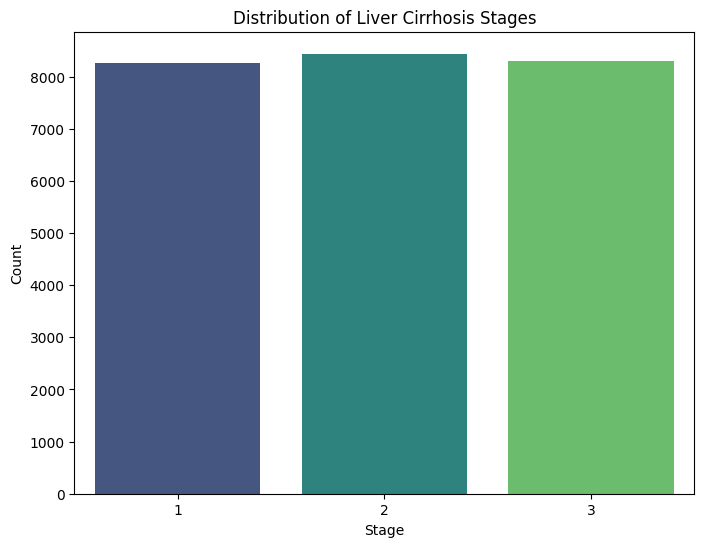

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Stage', palette='viridis')
plt.title('Distribution of Liver Cirrhosis Stages')
plt.xlabel('Stage')
plt.ylabel('Count')
plt.show()

In [ ]:
conti_var = ['N_Days', 'Age', 'Bilirubin', 'Cholesterol' , 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
print('No. Continuous Variables: ', len(conti_var))


No. Continuous Variables:  11


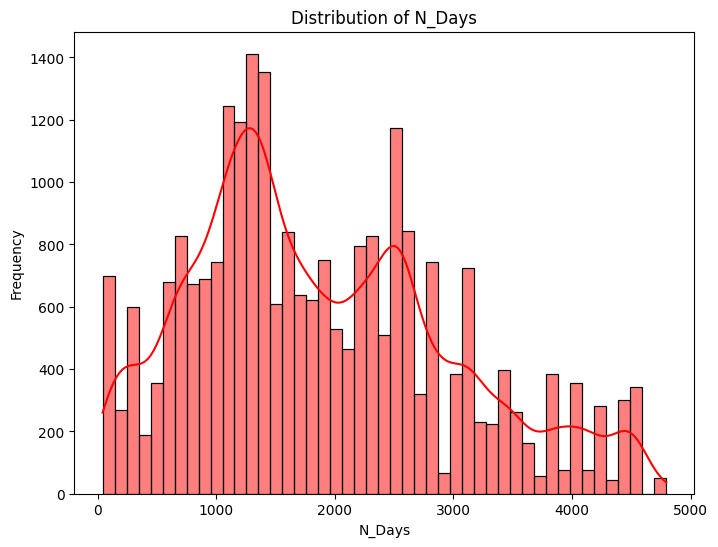

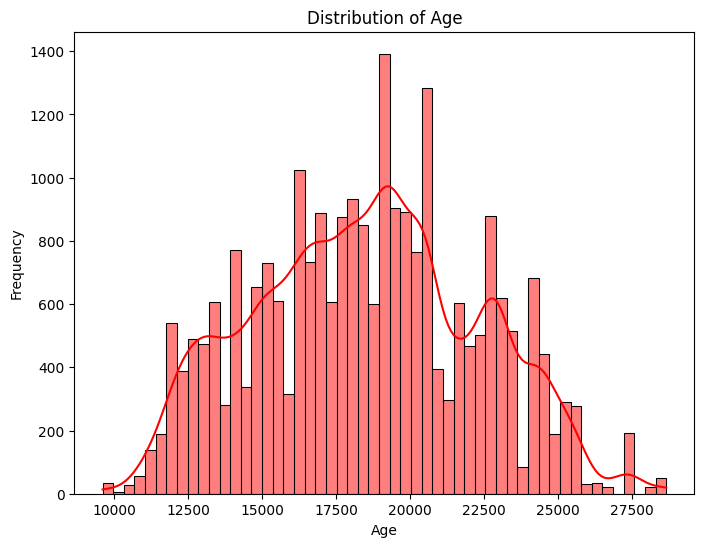

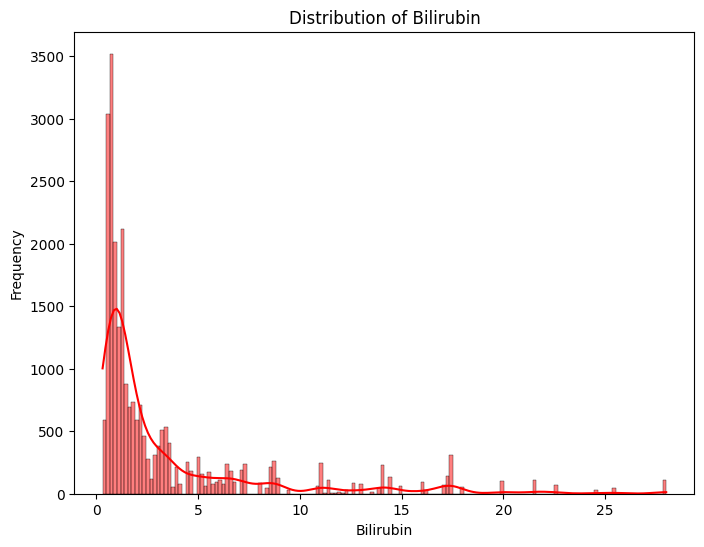

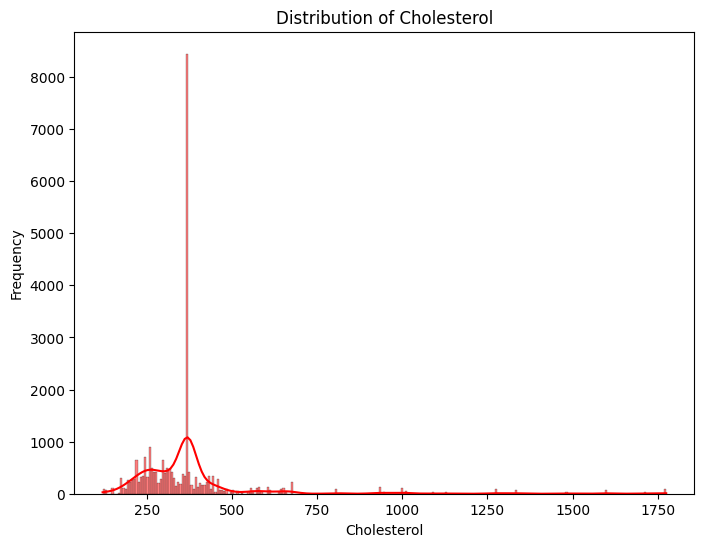

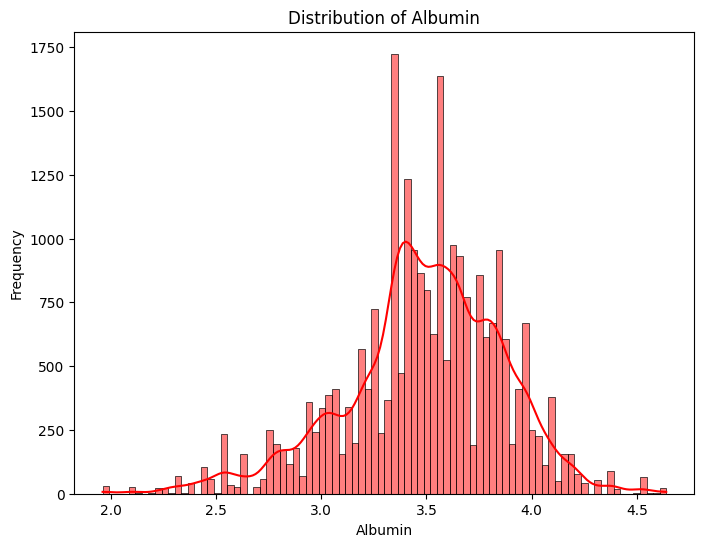

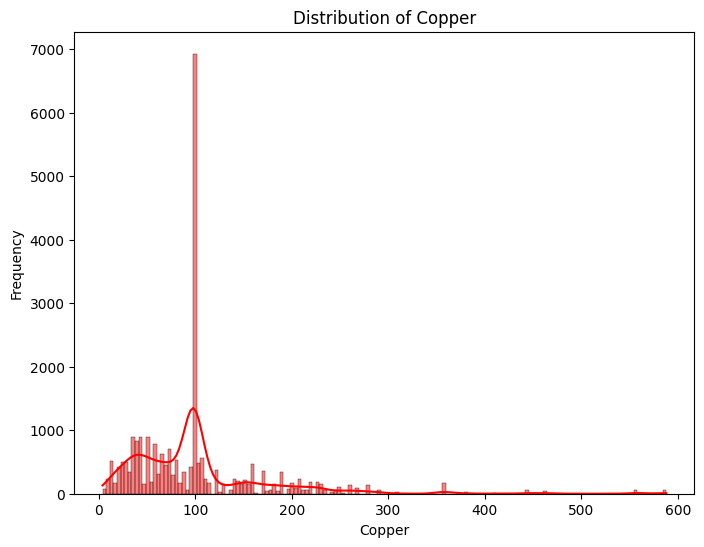

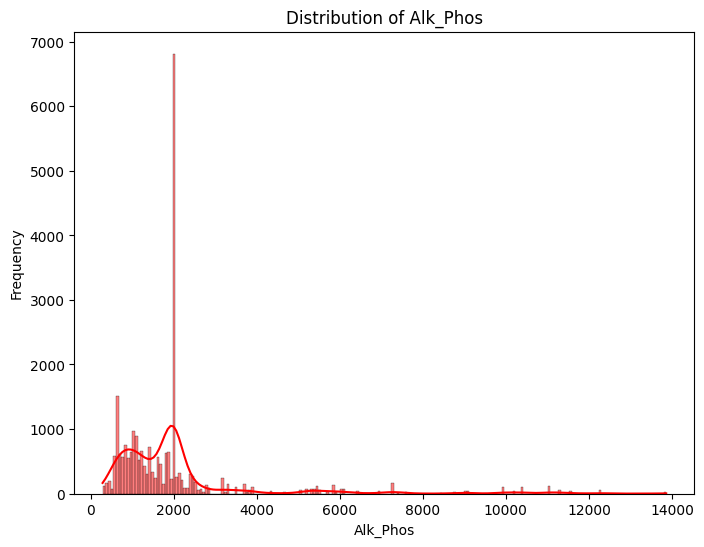

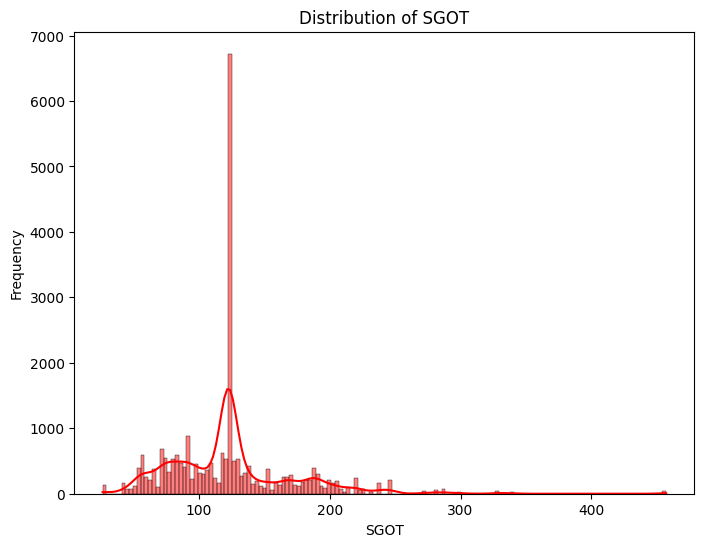

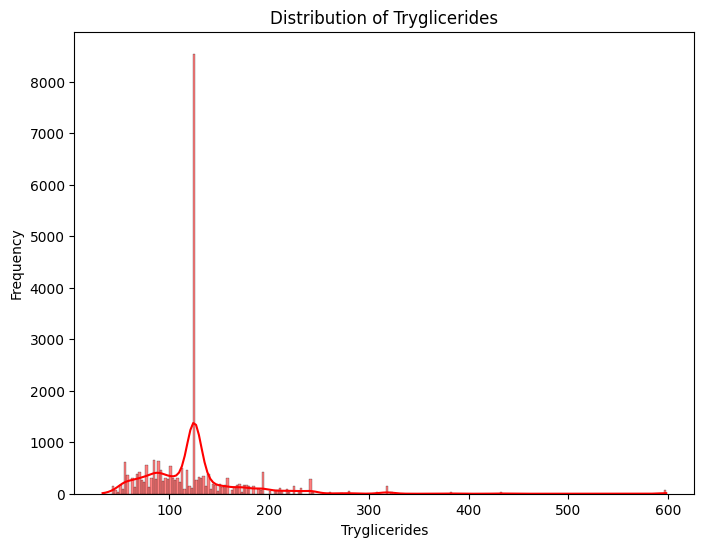

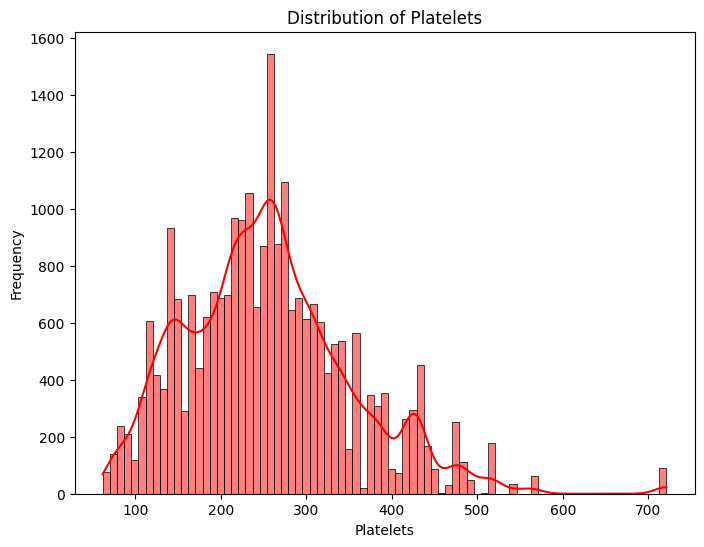

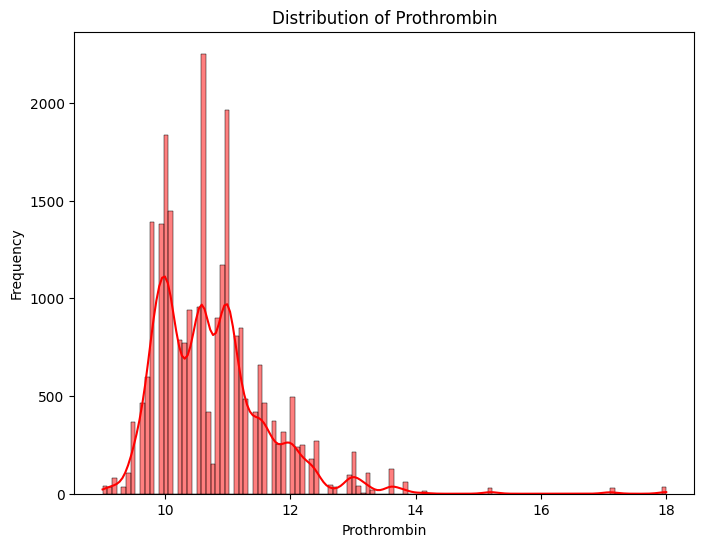

In [ ]:
for col in conti_var:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=col, kde=True, color='red')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
conti_col_skewness = {}
for col in conti_var:
  skewness = df[col].skew()
  print(f'Skewness of {col}: {skewness:.2f}')
  conti_col_skewness[col] = round(skewness, 2)

Skewness of N_Days: 0.54
Skewness of Age: 0.08
Skewness of Bilirubin: 2.57
Skewness of Cholesterol: 4.11
Skewness of Albumin: -0.53
Skewness of Copper: 2.51
Skewness of Alk_Phos: 3.39
Skewness of SGOT: 1.41
Skewness of Tryglicerides: 3.28
Skewness of Platelets: 0.76
Skewness of Prothrombin: 1.86


In [ ]:
conti_col_skewness

{'N_Days': np.float64(0.54),
 'Age': np.float64(0.08),
 'Bilirubin': np.float64(2.57),
 'Cholesterol': np.float64(4.11),
 'Albumin': np.float64(-0.53),
 'Copper': np.float64(2.51),
 'Alk_Phos': np.float64(3.39),
 'SGOT': np.float64(1.41),
 'Tryglicerides': np.float64(3.28),
 'Platelets': np.float64(0.76),
 'Prothrombin': np.float64(1.86)}

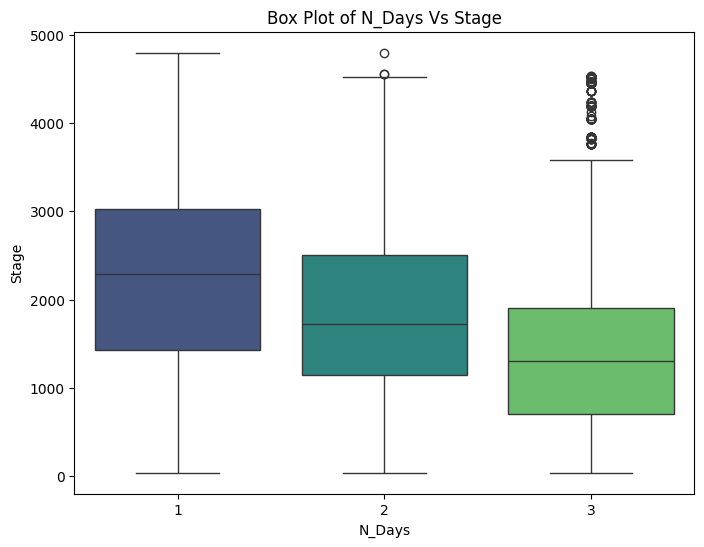

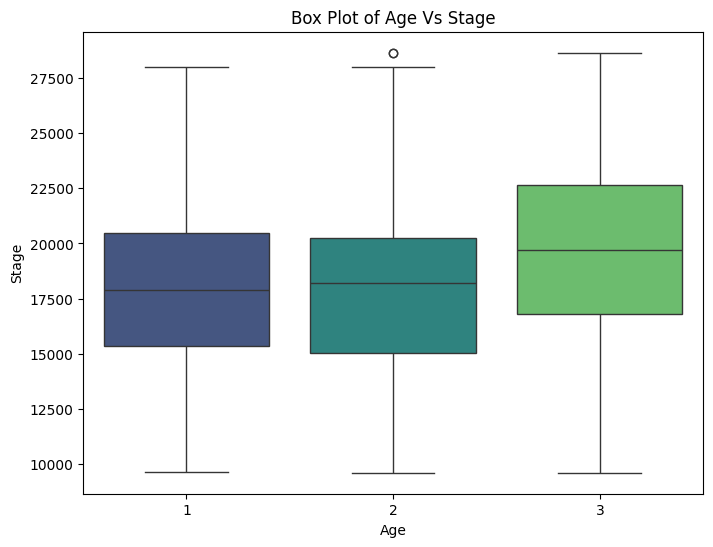

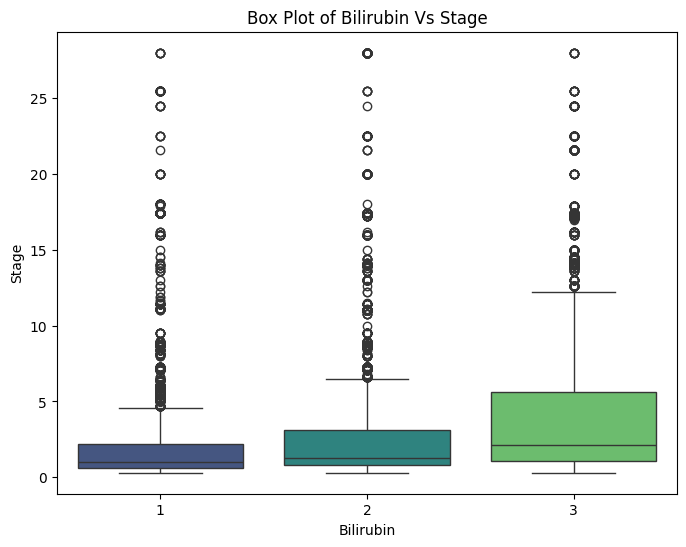

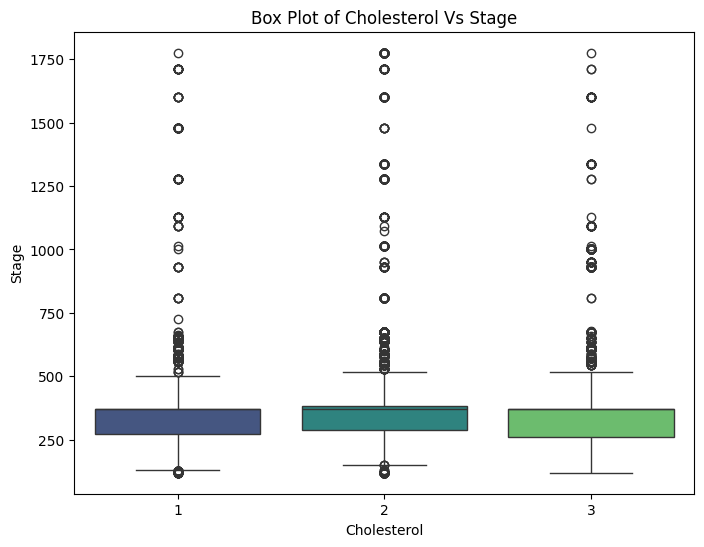

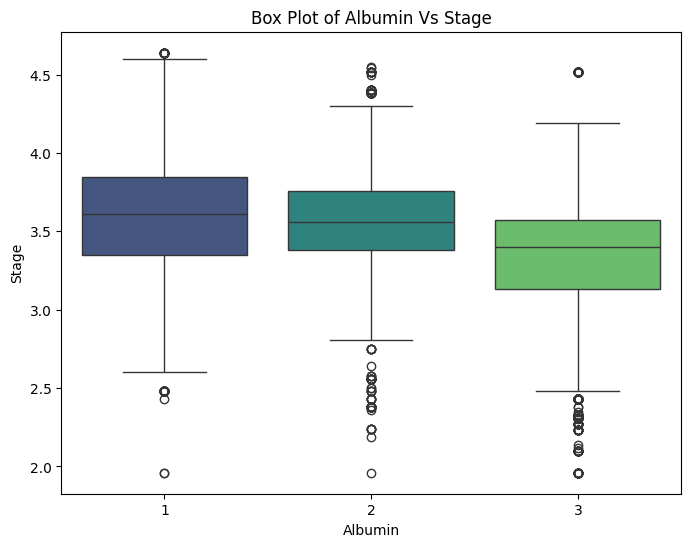

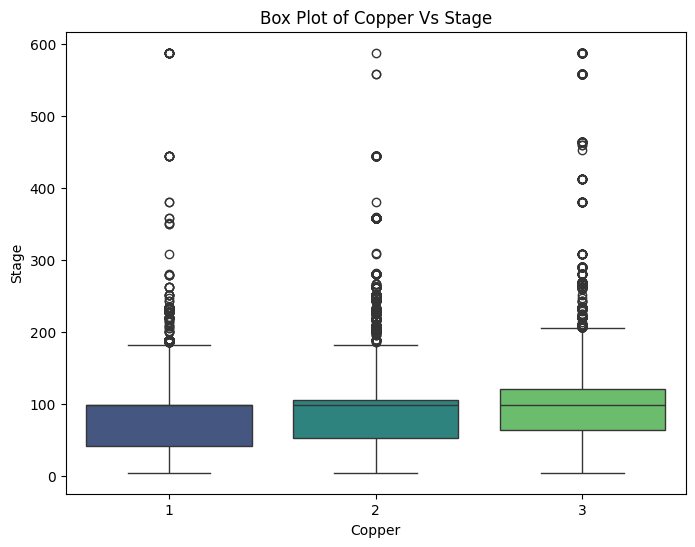

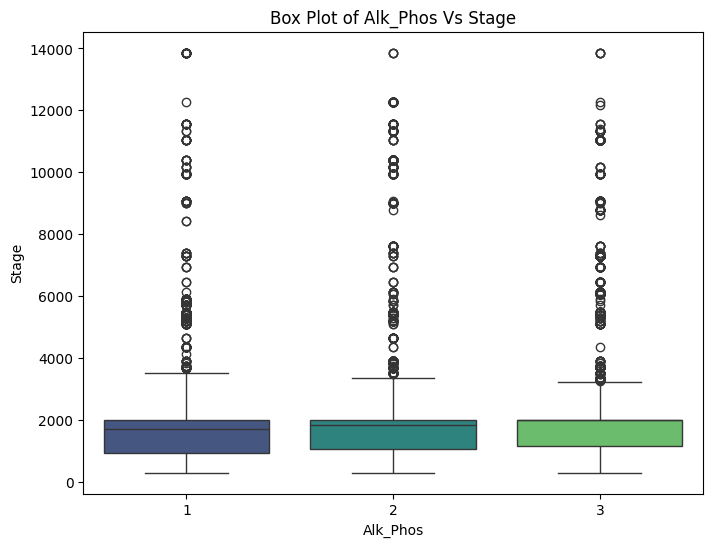

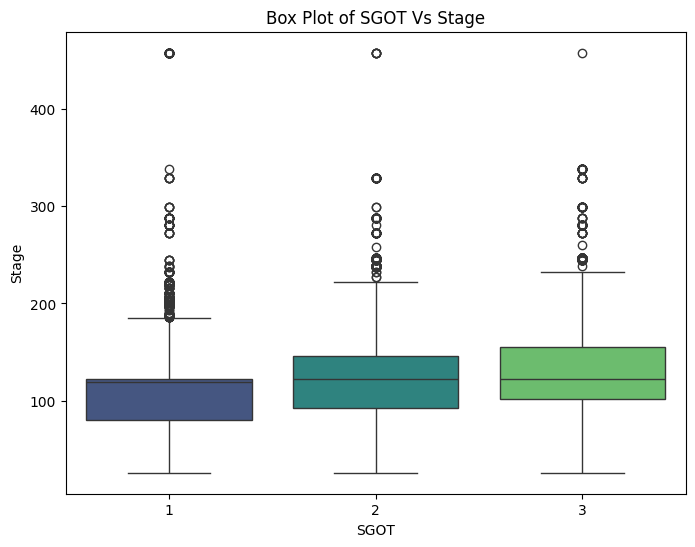

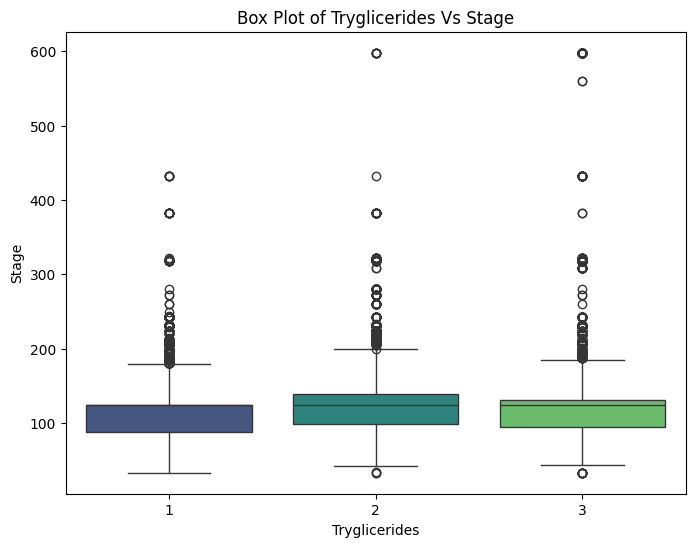

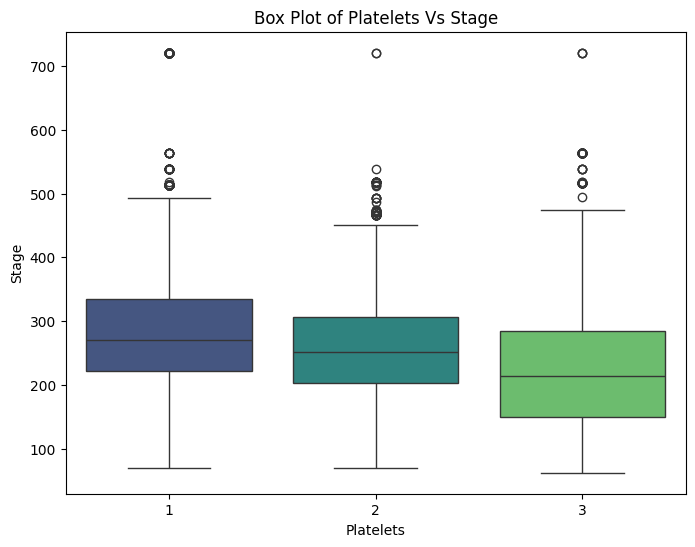

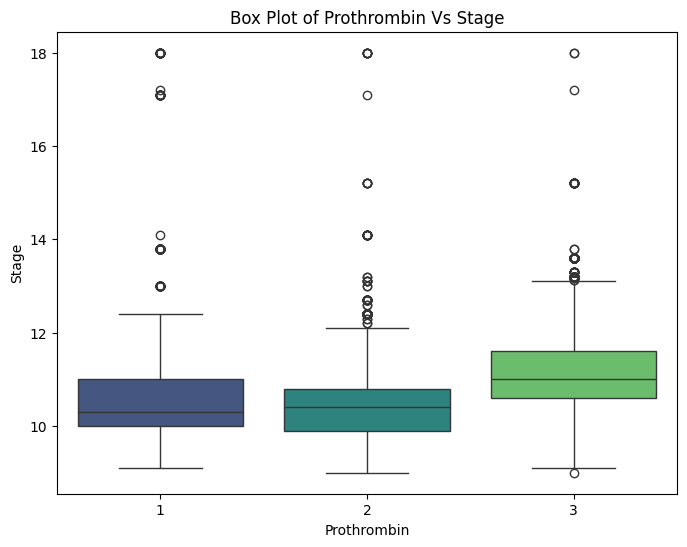

In [ ]:
for col in conti_var:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='Stage', y=col, color='lightblue', palette='viridis')
    plt.title(f'Box Plot of {col} Vs Stage')
    plt.xlabel(col)
    plt.ylabel('Stage')
    plt.show()

In [ ]:
from scipy import stats

print("--- One-Way ANOVA Test (Continuous Variables vs. Stage) ---")
print("\n")

# Get unique stages for grouping
stages = df['Stage'].unique()
stages.sort_values()

for col in conti_var:
    # Create a list of data for each stage for the current continuous variable
    data_by_stage = [df[df['Stage'] == stage][col] for stage in stages]

    # Perform one-way ANOVA test
    f_statistic, p_value = stats.f_oneway(*data_by_stage)

    print(f"ANOVA for {col} across Stages:")
    print(f"  F-statistic: {f_statistic:.3f}")
    print(f"  P-value: {p_value:.3f}")

    # Determine significance (common alpha is 0.05)
    alpha = 0.05
    if p_value < alpha:
        print(f"  Conclusion: There is a statistically significant difference in {col} across the different stages (p < {alpha}).")
    else:
        print(f"  Conclusion: There is NO statistically significant difference in {col} across the different stages (p >= {alpha}).")
    print("\n")

--- One-Way ANOVA Test (Continuous Variables vs. Stage) ---


ANOVA for N_Days across Stages:
  F-statistic: 1331.959
  P-value: 0.000
  Conclusion: There is a statistically significant difference in N_Days across the different stages (p < 0.05).


ANOVA for Age across Stages:
  F-statistic: 491.719
  P-value: 0.000
  Conclusion: There is a statistically significant difference in Age across the different stages (p < 0.05).


ANOVA for Bilirubin across Stages:
  F-statistic: 365.293
  P-value: 0.000
  Conclusion: There is a statistically significant difference in Bilirubin across the different stages (p < 0.05).


ANOVA for Cholesterol across Stages:
  F-statistic: 164.227
  P-value: 0.000
  Conclusion: There is a statistically significant difference in Cholesterol across the different stages (p < 0.05).


ANOVA for Albumin across Stages:
  F-statistic: 1028.297
  P-value: 0.000
  Conclusion: There is a statistically significant difference in Albumin across the different stages (p < 0.0

### Correlation Heatmap of Continuous Variables and Stage

Let's visualize the correlation matrix between all continuous variables and the 'Stage' column using a heatmap. This will help identify linear relationships and how strongly each continuous variable is related to the target 'Stage'.

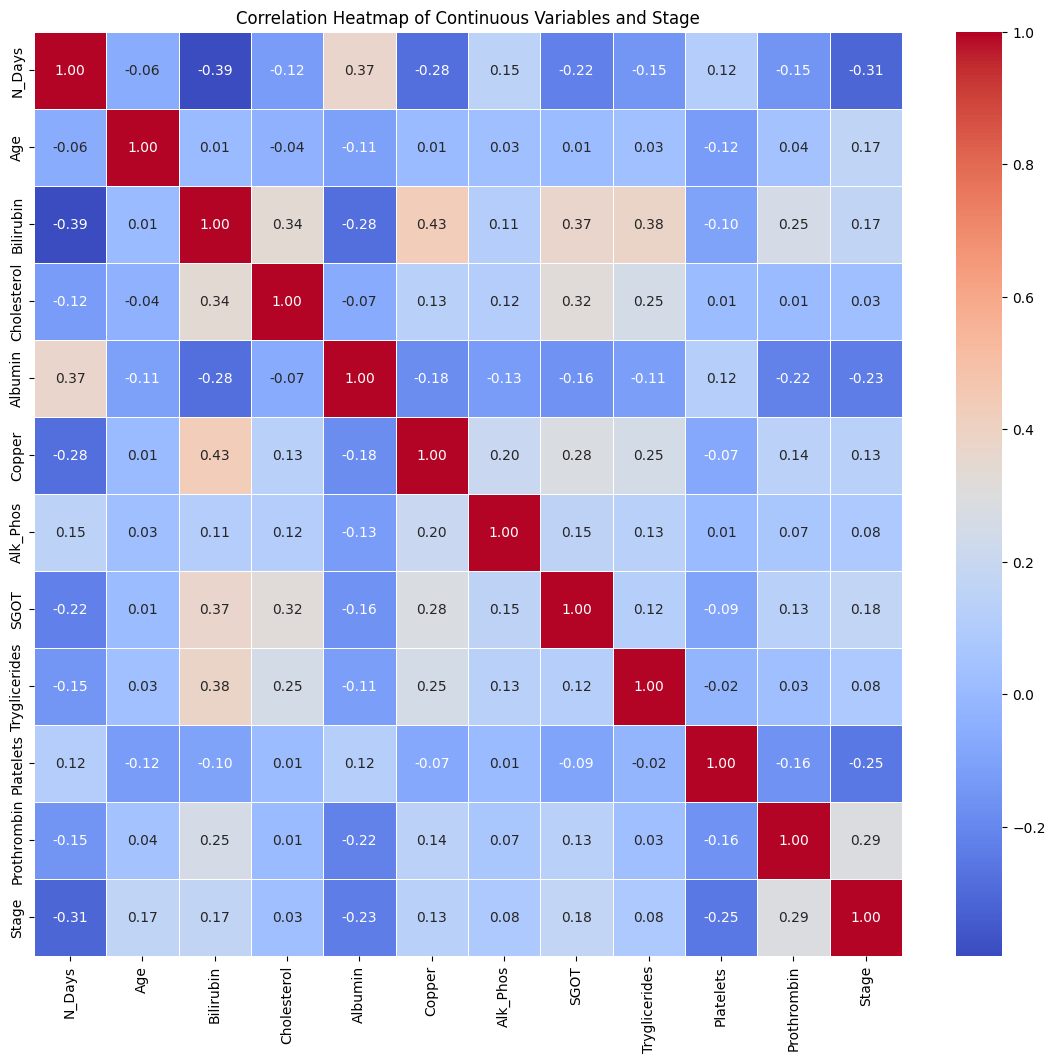

In [ ]:
# Combine continuous variables and the 'Stage' column
all_cols = conti_var + ['Stage']

# Calculate the correlation matrix
correlation_matrix = df[all_cols].corr()

# Plot the heatmap
plt.figure(figsize=(14, 12)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Continuous Variables and Stage')
plt.show()

In [ ]:
cate_var = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
print('No. Categorical Variables: ', len(cate_var))

No. Categorical Variables:  7


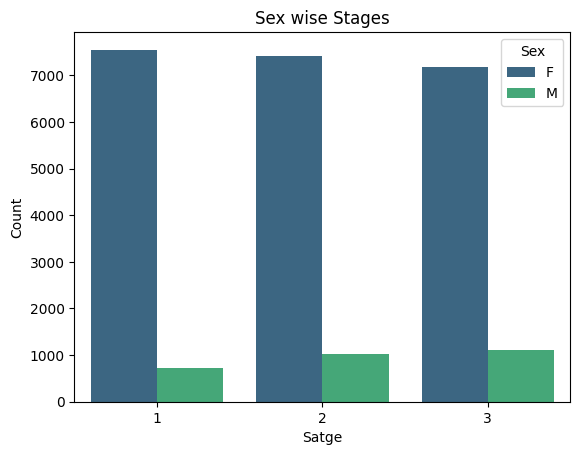

In [ ]:
sns.countplot(data=df, x='Stage',palette='viridis', hue='Sex')
plt.title('Sex wise Stages')
plt.xlabel('Satge')
plt.ylabel('Count')
plt.show()

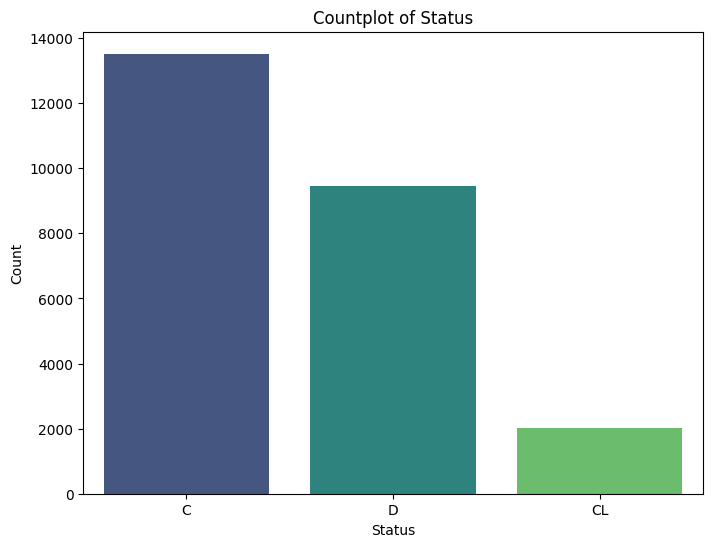

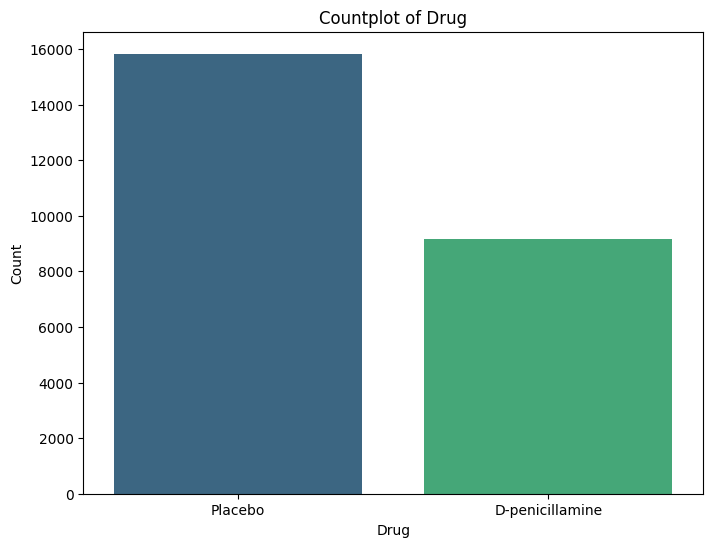

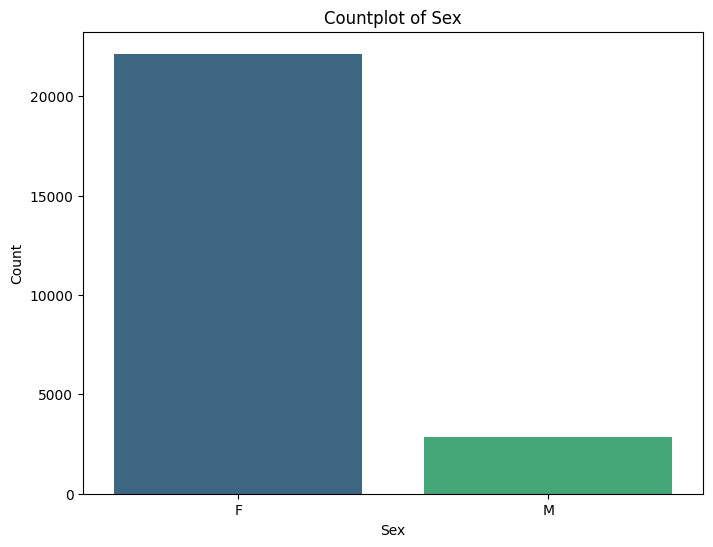

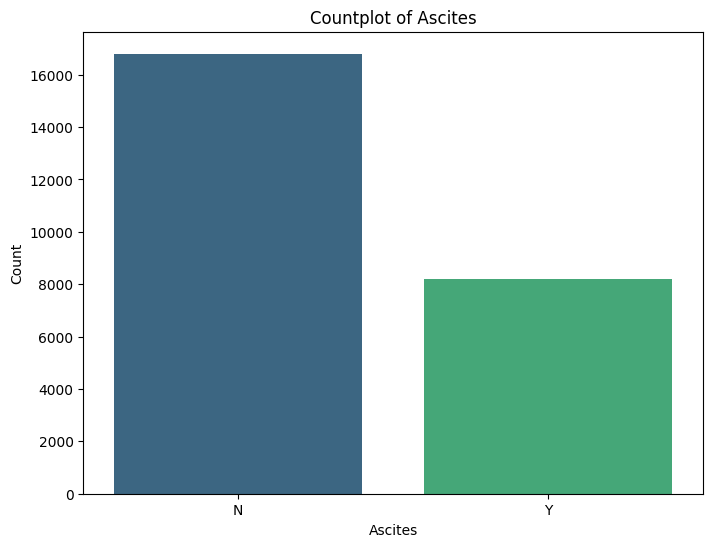

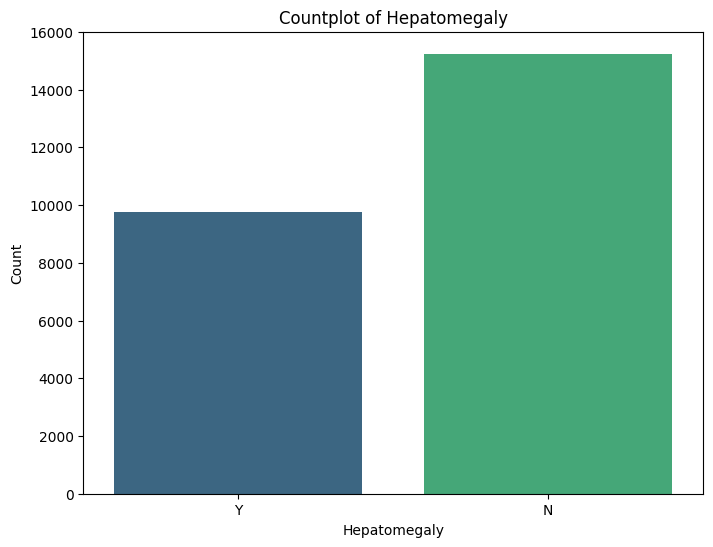

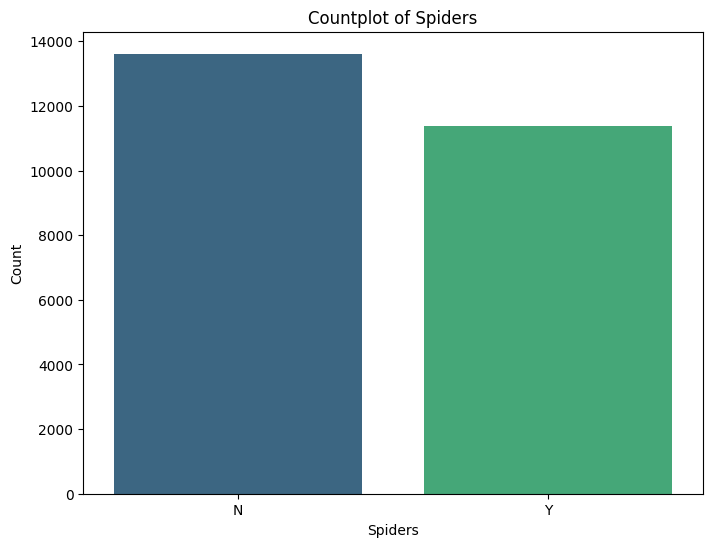

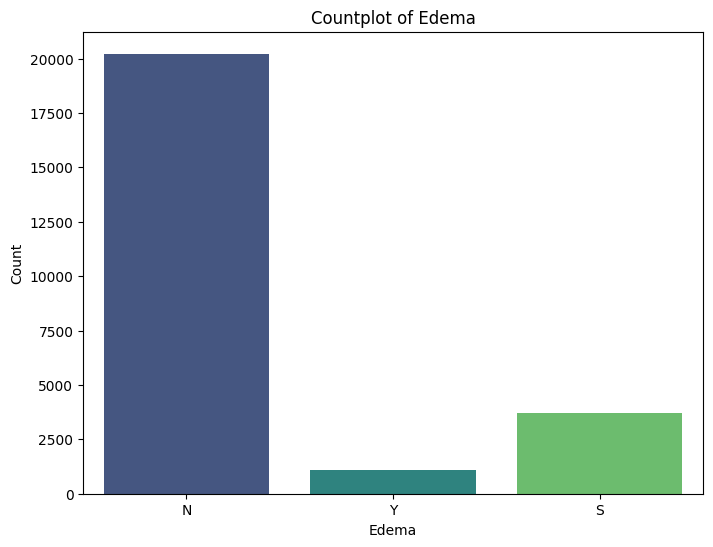

In [ ]:
for col in cate_var:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

### Stacked Bar Plots of Categorical Variables vs. Stage

Let's visualize the distribution of each categorical variable across the different 'Stage' values using stacked bar plots. This will help us understand how the categories within each feature are distributed for each liver cirrhosis stage.

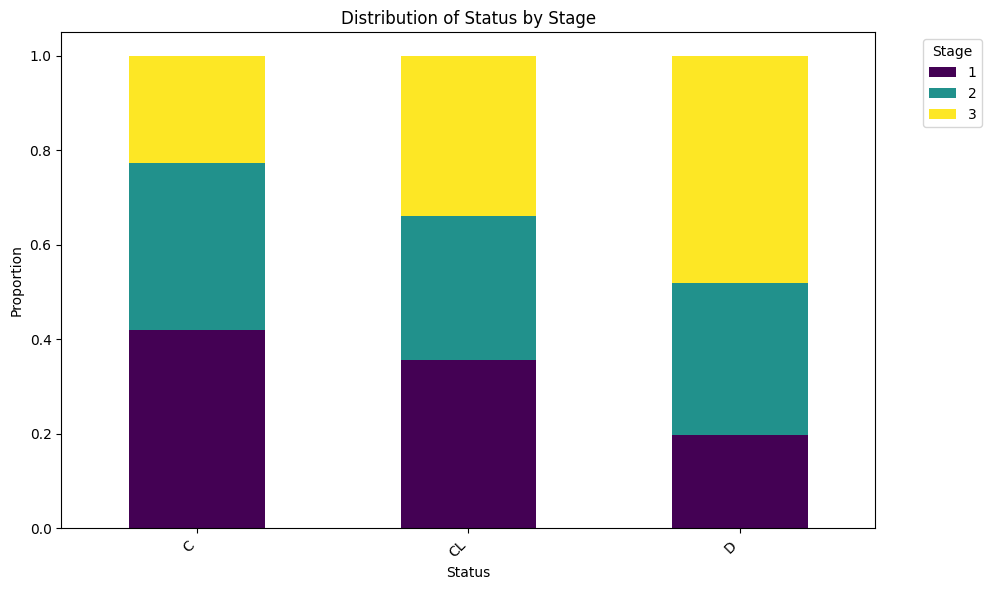

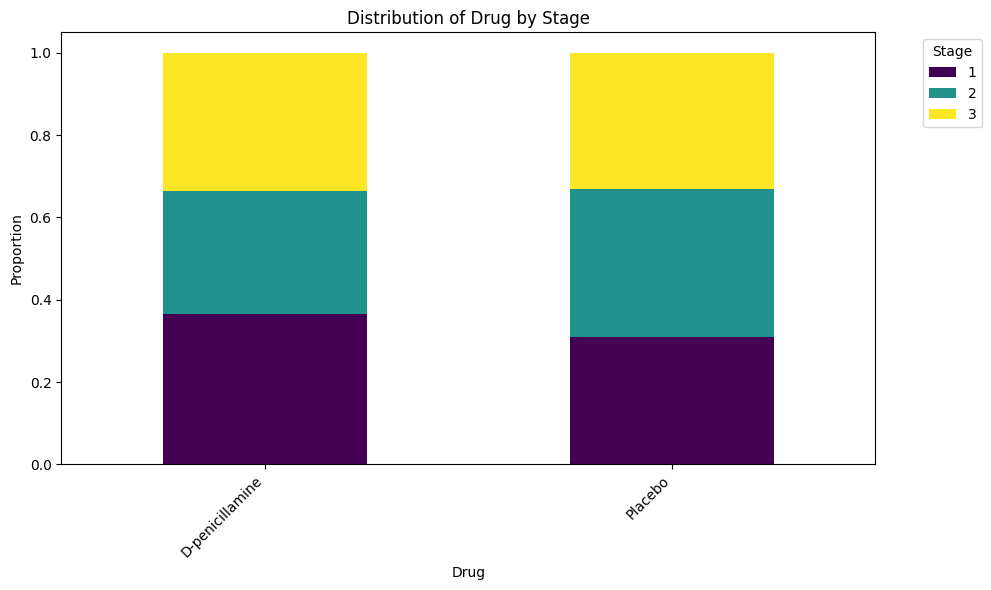

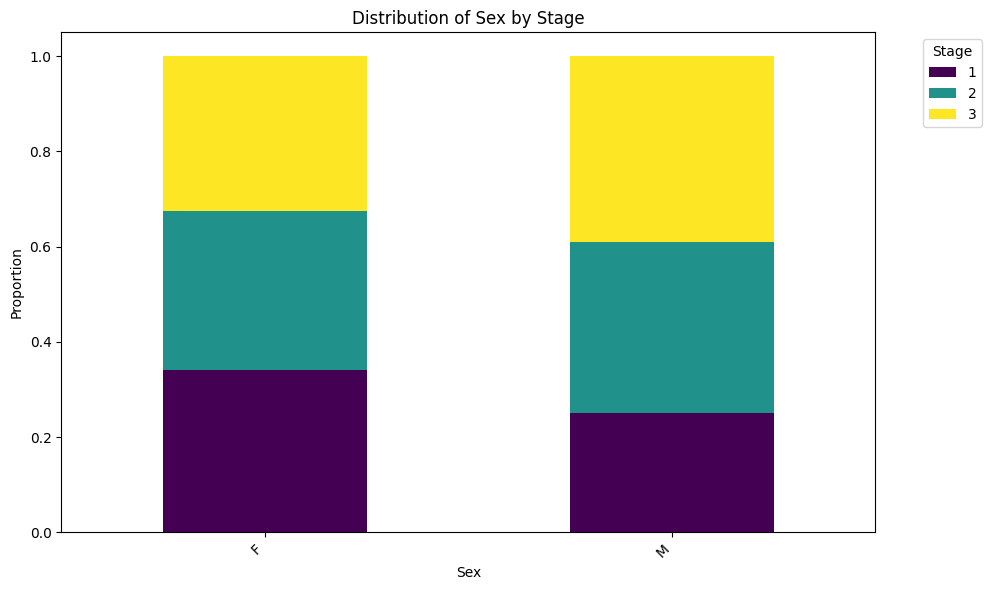

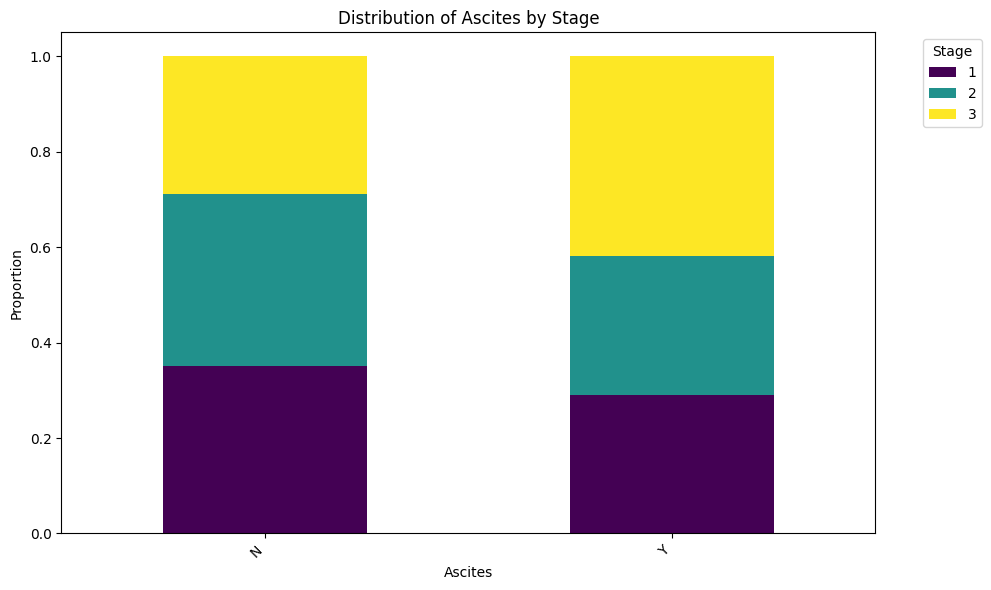

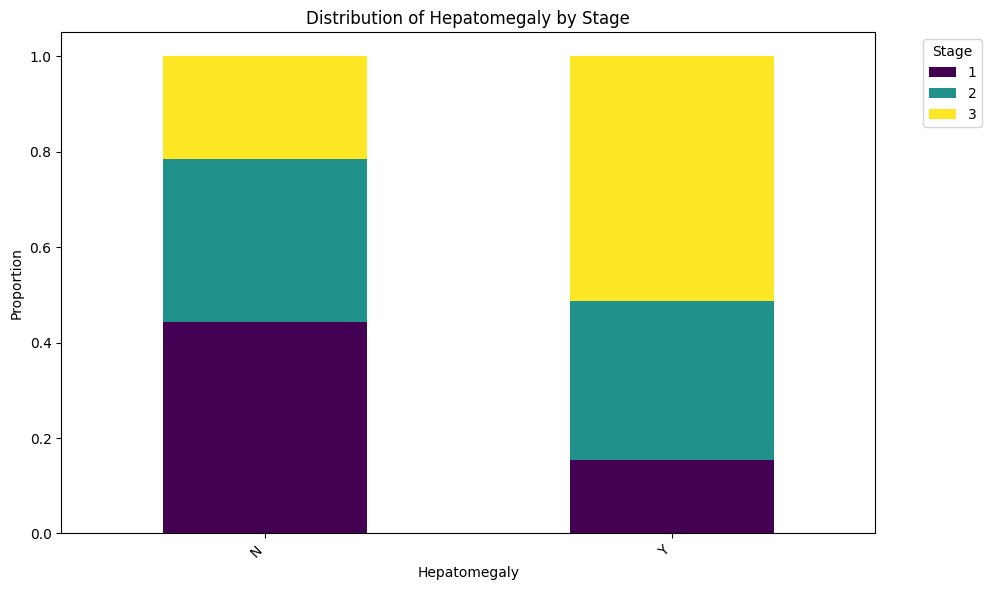

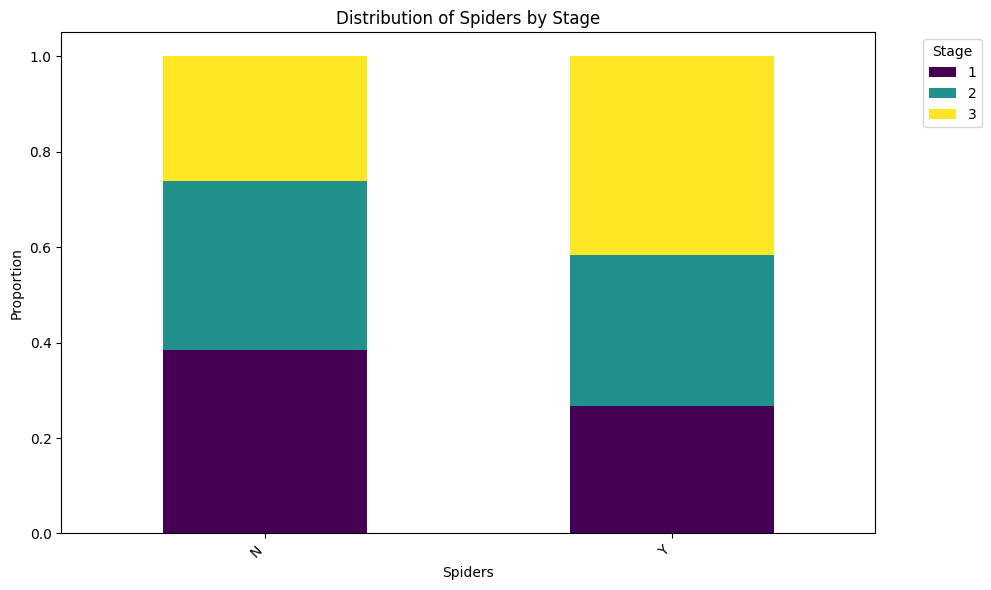

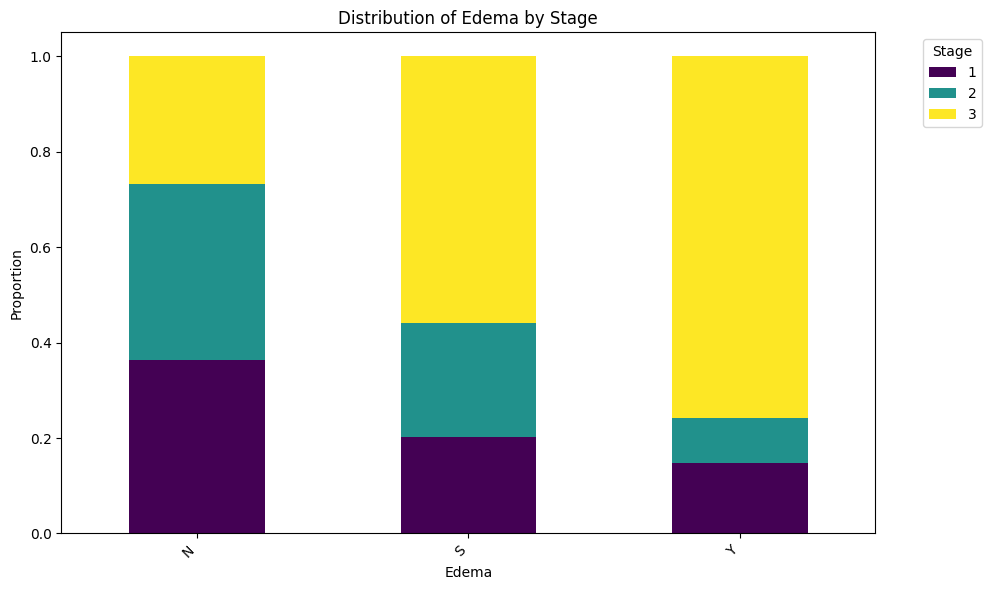

In [ ]:
for col in cate_var:
    # Create a crosstab to get counts of each category per stage
    crosstab_df = pd.crosstab(df[col], df['Stage'])

    # Normalize the crosstab to show proportions
    crosstab_df_norm = crosstab_df.div(crosstab_df.sum(1), axis=0)

    # Plotting the stacked bar chart
    plt.figure(figsize=(10, 6))
    crosstab_df_norm.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())

    plt.title(f'Distribution of {col} by Stage')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
df['Edema'].unique()

array(['N', 'Y', 'S'], dtype=object)

### Meaning of 'S' in the 'Edema' Column

The 'Edema' column typically signifies the presence of fluid retention or swelling. While 'N' commonly stands for 'No' (no edema) and 'Y' for 'Yes' (edema present), the 'S' value often represents 'Slight' or 'Scant' edema. This indicates a mild or minimal degree of swelling that is not as prominent as what would be classified as 'Y'.

It is important to note that without explicit data documentation, this is an interpretation based on common medical abbreviations. If the precise definition of 'S' is critical for your analysis, it is always best to consult the original data source or domain expert for definitive clarification.

### Chi-Square Test for Categorical Variables vs. Stage

Now, let's perform a Chi-Square test for each categorical variable against the 'Stage' column. This test will help us determine if there is a statistically significant association between the categorical features and the liver cirrhosis stages.

In [ ]:
from scipy.stats import chi2_contingency

print("--- Chi-Square Test (Categorical Variables vs. Stage) ---")
print("\n")

for col in cate_var:
    # Create a contingency table
    contingency_table = pd.crosstab(df[col], df['Stage'])

    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"Chi-Square Test for {col} across Stages:")
    print(f"  Chi2 Statistic: {chi2:.3f}")
    print(f"  P-value: {p_value:.3f}")

    # Determine significance (common alpha is 0.05)
    alpha = 0.05
    if p_value < alpha:
        print(f"  Conclusion: There is a statistically significant association between {col} and Stage (p < {alpha}).")
    else:
        print(f"  Conclusion: There is NO statistically significant association between {col} and Stage (p >= {alpha}).")
    print("\n")

--- Chi-Square Test (Categorical Variables vs. Stage) ---


Chi-Square Test for Status across Stages:
  Chi2 Statistic: 1938.356
  P-value: 0.000
  Conclusion: There is a statistically significant association between Status and Stage (p < 0.05).


Chi-Square Test for Drug across Stages:
  Chi2 Statistic: 121.589
  P-value: 0.000
  Conclusion: There is a statistically significant association between Drug and Stage (p < 0.05).


Chi-Square Test for Sex across Stages:
  Chi2 Statistic: 102.261
  P-value: 0.000
  Conclusion: There is a statistically significant association between Sex and Stage (p < 0.05).


Chi-Square Test for Ascites across Stages:
  Chi2 Statistic: 425.682
  P-value: 0.000
  Conclusion: There is a statistically significant association between Ascites and Stage (p < 0.05).


Chi-Square Test for Hepatomegaly across Stages:
  Chi2 Statistic: 3120.400
  P-value: 0.000
  Conclusion: There is a statistically significant association between Hepatomegaly and Stage (p < 0.05).

